# DBSCAN Clustering - Density-Based Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups together points that are closely packed in high-density regions, while marking isolated points as noise or outliers. Unlike K-Means which assumes spherical clusters, DBSCAN can find clusters of arbitrary shape.

## Step 1: Import Required Libraries

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

## Key Parameters in DBSCAN

### **eps (epsilon)** - Neighborhood Radius
- Defines the distance threshold to find neighbors around each point
- If distance ≤ eps, points are neighbors
- **Too small eps**: Most points become noise
- **Too large eps**: Clusters merge together
- Determine using k-distance graph method

### **min_samples** - Minimum Neighborhood Points
- Minimum number of neighbors (including the point itself) to form a dense region
- Common rule: min_samples ≥ dimensions + 1
- Default: min_samples = 3
- Higher values = stricter clustering (more noise points)

### **Point Types in DBSCAN**
1. **Core Point**: Has ≥ min_samples neighbors within eps radius
2. **Border Point**: Not core, but within eps of a core point
3. **Noise Point**: Isolated, not within eps of any core point

## Step 2: Create Synthetic Dataset

Generate a dataset with 4 clusters of varying densities to demonstrate DBSCAN's capability with different cluster shapes.

In [25]:
# Generate synthetic dataset with NON-SPHERICAL clusters (perfect for DBSCAN!)
from sklearn.datasets import make_moons

# Create two interleaving half circles (moons) - K-Means fails, DBSCAN excels
X_moons, y_moons = make_moons(n_samples=200, noise=0.08, random_state=42)

# Add varying density clusters: tight cluster + sparse cluster
X_tight = np.random.randn(80, 2) * 0.3 + np.array([3, 3])  # Dense cluster
X_sparse = np.random.randn(50, 2) * 0.7 + np.array([-3, 3])  # Sparse cluster

# Combine all data
X = np.vstack([X_moons, X_tight, X_sparse])
y_true = np.concatenate([y_moons, np.full(80, 2), np.full(50, 3)])

# Add random noise points (outliers)
noise_points = np.random.uniform(-3, 4, (20, 2))
X = np.vstack([X, noise_points])
y_true = np.concatenate([y_true, np.full(20, -1)])  # -1 for noise

# Standardize features
X = StandardScaler().fit_transform(X)

print(f"Dataset shape: {X.shape}")
print(f"Data composition:")
print(f"  - Moons (crescent clusters): 200 points")
print(f"  - Dense cluster: 80 points")
print(f"  - Sparse cluster: 50 points")
print(f"  - Random noise: 20 points")
print(f"\nWhy this data highlights DBSCAN:")
print(f"  ✓ Non-spherical (moons) - K-Means will struggle")
print(f"  ✓ Varying densities - K-Means assigns equally")
print(f"  ✓ Natural outliers - K-Means forces them into clusters")

Dataset shape: (350, 2)
Data composition:
  - Moons (crescent clusters): 200 points
  - Dense cluster: 80 points
  - Sparse cluster: 50 points
  - Random noise: 20 points

Why this data highlights DBSCAN:
  ✓ Non-spherical (moons) - K-Means will struggle
  ✓ Varying densities - K-Means assigns equally
  ✓ Natural outliers - K-Means forces them into clusters


## Step 3: Apply DBSCAN Clustering

Apply DBSCAN with eps=0.3 and min_samples=5. Points labeled as -1 are noise/outliers.

In [26]:
# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)

# Count clusters and noise points
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Unique labels: {sorted(set(labels))}")

Number of clusters: 3
Number of noise points: 20
Unique labels: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]


## Step 4: Visualize DBSCAN Results

Visualize clusters with core points (circles) and border/noise points (X marks).

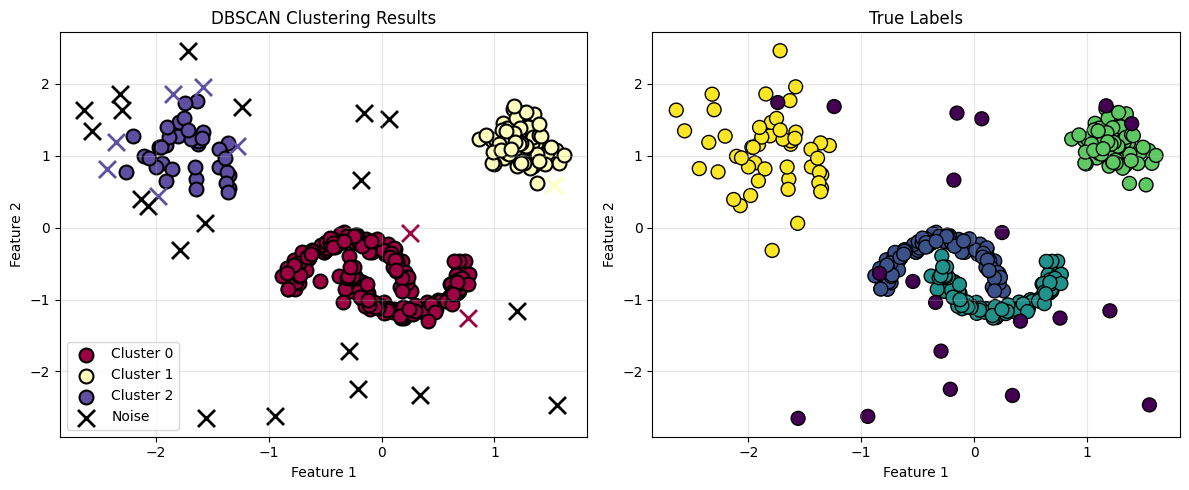

Core points (circles): Density-connected points
Border points (x marks): Near clusters but not core
Noise points (black x): Isolated points


In [27]:
# Identify core samples
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# Plot results
plt.figure(figsize=(12, 5))

# Plot 1: DBSCAN Results
plt.subplot(1, 2, 1)
colors = plt.cm.Spectral(np.linspace(0, 1, n_clusters))

for k, col in zip(range(n_clusters), colors):
    class_member_mask = (labels == k)
    
    # Plot core points
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker='o', s=100, 
                edgecolors='k', linewidth=1.5, label=f'Cluster {k}')
    
    # Plot border points
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker='x', s=150, 
                edgecolors='k', linewidth=2)

# Plot noise points
noise_mask = (labels == -1)
plt.scatter(X[noise_mask, 0], X[noise_mask, 1], c='black', marker='x', 
            s=150, label='Noise', linewidth=2)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN Clustering Results')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: True Labels
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=100, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('True Labels')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Core points (circles): Density-connected points")
print(f"Border points (x marks): Near clusters but not core")
print(f"Noise points (black x): Isolated points")

## Step 5: Evaluate DBSCAN Clustering

Use Silhouette Score and Adjusted Rand Index to evaluate clustering quality.

In [28]:
# Evaluation metrics
# Silhouette Score: -1 to 1, higher is better (excludes noise points)
silhouette = silhouette_score(X[labels != -1], labels[labels != -1])

# Adjusted Rand Index: 0 to 1, compares with true labels
ari = adjusted_rand_score(y_true, labels)

print("=" * 50)
print("DBSCAN Evaluation Metrics")
print("=" * 50)
print(f"Silhouette Coefficient: {silhouette:.3f}")
print(f"  Range: [-1, 1] | Higher = Better")
print(f"  Interpretation: {['Poor', 'Fair', 'Good', 'Excellent'][min(3, max(0, int((silhouette + 1) * 2)))]}")
print()
print(f"Adjusted Rand Index: {ari:.3f}")
print(f"  Range: [0, 1] | Higher = Better")
print(f"  > 0.8: Good recovery | < 0.5: Poor recovery")
print(f"  Interpretation: {['Poor', 'Fair', 'Good', 'Excellent'][min(3, int(ari * 4))]}")
print("=" * 50)

DBSCAN Evaluation Metrics
Silhouette Coefficient: 0.726
  Range: [-1, 1] | Higher = Better
  Interpretation: Excellent

Adjusted Rand Index: 0.570
  Range: [0, 1] | Higher = Better
  > 0.8: Good recovery | < 0.5: Poor recovery
  Interpretation: Good


## Step 6: Tune DBSCAN Parameters

Test different eps and min_samples values to see their impact on clustering.

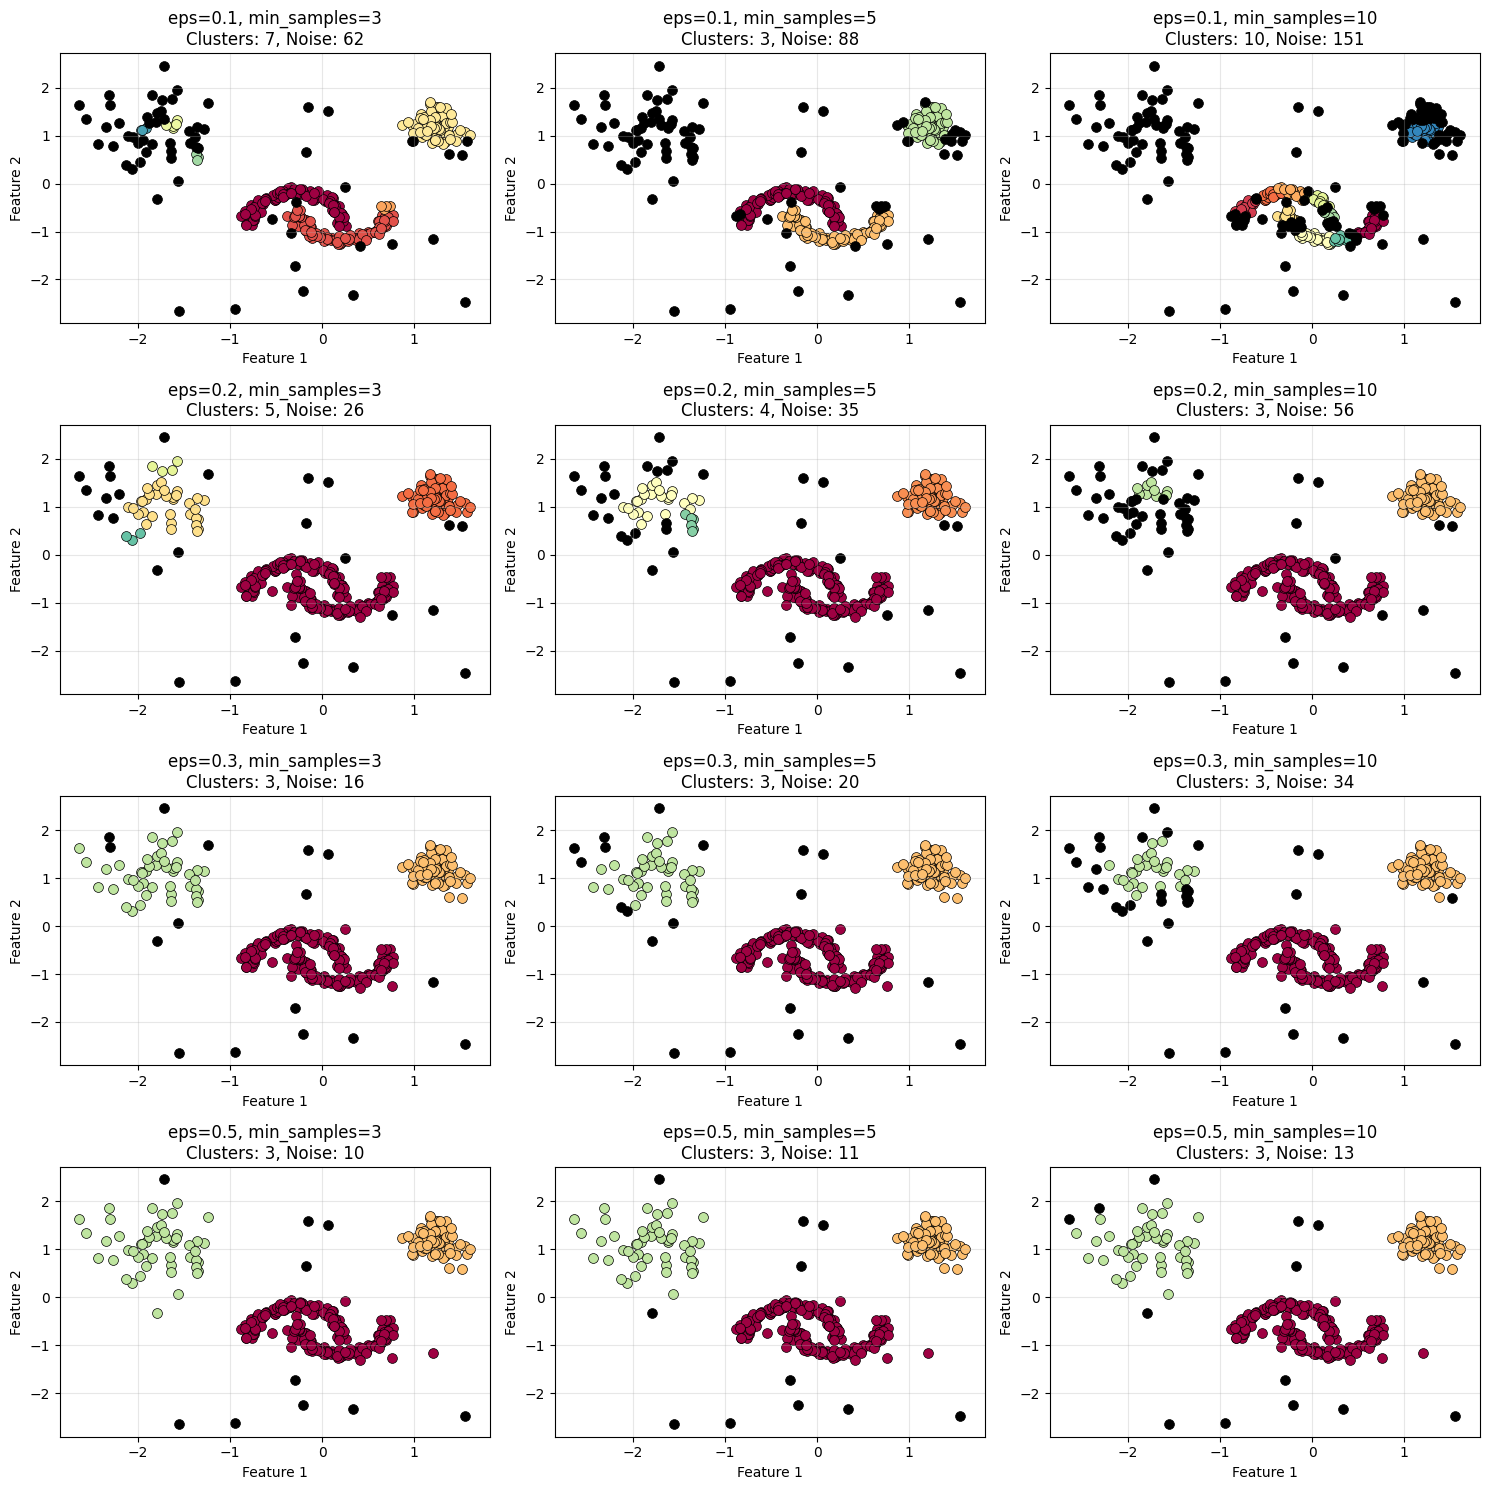

Observation: eps affects neighborhood radius, min_samples affects density requirement


In [ ]:
# Test different parameter combinations
eps_values = [0.1, 0.2, 0.3, 0.5]
min_samples_values = [3, 5, 10]

fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(15, 15))

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        dbscan_test = DBSCAN(eps=eps, min_samples=min_samples)
        labels_test = dbscan_test.fit_predict(X)
        
        n_clusters_test = len(set(labels_test)) - (1 if -1 in labels_test else 0)
        n_noise_test = list(labels_test).count(-1)
        
        ax = axes[i, j]
        
        # Plot clusters
        unique_labels = set(labels_test)
        colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
        
        for k, col in zip(unique_labels, colors):
            if k == -1:``
                col = 'black'
            
            class_member_mask = (labels_test == k)
            xy = X[class_member_mask]
            ax.scatter(xy[:, 0], xy[:, 1], c=[col], s=50, edgecolors='k', linewidth=0.5)
        
        ax.set_title(f'eps={eps}, min_samples={min_samples}\nClusters: {n_clusters_test}, Noise: {n_noise_test}')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation: eps affects neighborhood radius, min_samples affects density requirement")

## DBSCAN Advantages & Limitations

### ✅ Advantages
- **No need to specify K**: Automatically discovers number of clusters
- **Arbitrary cluster shapes**: Finds crescent, ring, or irregular clusters (not just spheres)
- **Handles noise/outliers**: Identifies and isolates anomalies
- **Density-aware**: Works well with varying cluster densities

### ❌ Limitations
- **Parameter sensitive**: Results heavily depend on eps and min_samples selection
- **High-dimensional issues**: Distance metrics become less meaningful in high dimensions
- **Scalability**: Slow on very large datasets (O(n²) complexity)
- **Assumes Gaussian density**: May fail with non-uniform point distributions
- **Varying density problem**: Difficult when clusters have different densities

## DBSCAN vs K-Means Clustering

| Feature | DBSCAN | K-Means |
|---------|--------|---------|
| **Cluster Count** | Auto-discovered | Must specify K |
| **Cluster Shape** | Any arbitrary shape | Spherical/convex |
| **Outliers** | Identified as noise (-1) | Forced into clusters |
| **Parameters** | eps, min_samples | Only K |
| **Initialization** | No random init needed | Sensitive to init |
| **Scalability** | O(n²) - slower | O(n) - faster |
| **Best For** | Complex, non-spherical data | Well-defined, spherical clusters |

### When to use DBSCAN:
- Clusters have irregular shapes
- Need to identify outliers/noise
- Don't know cluster count beforehand
- Density variations in data

## Real-World Use Cases

1. **Anomaly Detection** - Identify fraud in transactions, network intrusions, or manufacturing defects
2. **Geospatial Analysis** - Find geographic clusters of earthquakes, crime, or disease outbreaks
3. **Image Segmentation** - Group pixels by density for background removal or object detection
4. **Traffic Pattern Analysis** - Identify congestion zones and traffic hotspots
5. **Customer Segmentation** - Find natural customer groups without pre-defining count
6. **Document Clustering** - Group similar documents by semantic density without knowing categories